#### Introduction to PyTorch: https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html

##### Quickstart

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
# torchvision library: https://pytorch.org/vision/stable/index.html
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
# PyTorch has two primitives to work with data: torch.utils.data.DataLoader and torch.utils.data.Dataset. 
# Dataset stores the samples and their corresponding labels, and DataLoader wraps an iterable around the Dataset.

In [3]:
# Every TorchVision Dataset includes two arguments: transform and target_transform to modify the samples and labels respectively.

training_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform = ToTensor()
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor()
)

In [4]:
batch_size = 64

# create data loaders:
# 1."num_workers" in PyTorch's DataLoader sets how many CPU subprocesses load data in parallel. 
#   Setting it >0 enables background data loading to keep the GPU busy and training efficient.
# 2.Map-style supports random access via index; iterable-style yields samples in sequence like a generator (streaming data).
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [5]:
# To define a neural network in PyTorch, we create a class that INHERITS from nn.Module. 
# 1. We define the layers of the network in the __init__ function and specify how data will pass through the network in the forward function. 
# 2. To accelerate operations in the neural network, we move it to the accelerator such as CUDA, MPS, MTIA, or XPU.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

# Define model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512,10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = MLP()
model = model.to(device)
print(model)

Using cuda device
MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [6]:
## Optimizing the model parameters: 

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred,y)

        # back propagation
        loss.backward() # Compute gradients of the loss with respect to the model parameters
        optimizer.step() # Update model parameters using the optimizer
        optimizer.zero_grad() # Clear the gradients for the next iteration

        if batch % 100 == 0:
            loss, current = loss.item(), (batch+1)*len(X)
            print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")

In [16]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(dim=1) == y).sum().item()
            break
    test_loss /= num_batches
    correct /= size
    print(f"Test error: \n accuracy: {(100*correct):>0.3f}%, Avg Loss: {test_loss:>8f} \n")

In [17]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1} \n -----")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1 
 -----
loss: 1.043825 [   64/60000]
loss: 1.065890 [ 6464/60000]
loss: 0.875888 [12864/60000]
loss: 1.028001 [19264/60000]
loss: 0.905637 [25664/60000]
loss: 0.932582 [32064/60000]
loss: 0.974101 [38464/60000]
loss: 0.923151 [44864/60000]
loss: 0.968587 [51264/60000]
loss: 0.898663 [57664/60000]
Test error: 
 accuracy: 0.410%, Avg Loss: 0.005777 

Epoch 2 
 -----
loss: 0.957742 [   64/60000]
loss: 0.999008 [ 6464/60000]
loss: 0.794986 [12864/60000]
loss: 0.963608 [19264/60000]
loss: 0.849068 [25664/60000]
loss: 0.863676 [32064/60000]
loss: 0.921274 [38464/60000]
loss: 0.872687 [44864/60000]
loss: 0.912319 [51264/60000]
loss: 0.848694 [57664/60000]
Test error: 
 accuracy: 0.420%, Avg Loss: 0.005505 

Epoch 3 
 -----
loss: 0.891014 [   64/60000]
loss: 0.948564 [ 6464/60000]
loss: 0.733838 [12864/60000]
loss: 0.915038 [19264/60000]
loss: 0.808790 [25664/60000]
loss: 0.811173 [32064/60000]
loss: 0.881402 [38464/60000]
loss: 0.836826 [44864/60000]
loss: 0.869493 [51264/60000]
loss:

In [18]:
# Saving model
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch model state to model.pth")

Saved PyTorch model state to model.pth


In [19]:
# Loading model
model = MLP().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

In [23]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"


##### Tensors

In [36]:
import torch 
import numpy as np

# from data
data = [[1,2], [2,3]]
x_data = torch.tensor(data)

# from np array
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

# from another tensor 
x_ones = torch.ones_like(x_data)
print(x_ones)

x_rand = torch.rand_like(x_data, dtype=torch.float)
print(x_rand)

tensor([[1, 1],
        [1, 1]])
tensor([[0.5975, 0.5209],
        [0.6713, 0.1419]])


In [40]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.1286, 0.3420, 0.0971],
        [0.4377, 0.0397, 0.3614]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [41]:
tensor = torch.rand(3,5)

print(tensor.shape, tensor.dtype, tensor.device)

torch.Size([3, 5]) torch.float32 cpu


In [52]:
tensor = torch.rand(4,4)
print(tensor)

tensor([[0.5961, 0.5175, 0.8561, 0.2980],
        [0.0961, 0.8230, 0.1073, 0.1052],
        [0.7243, 0.2409, 0.9421, 0.9413],
        [0.6637, 0.7620, 0.6361, 0.0497]])


In [57]:
t1 = torch.cat([tensor, tensor, tensor], dim=0)
t2 = torch.cat([tensor, tensor, tensor], dim=1)
t1.shape, t2.shape

(torch.Size([12, 4]), torch.Size([4, 12]))

In [75]:
# Matrix multiplication
tensor = torch.rand(4,4)

y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
print(f"{y1}, \n {y2}")

y3 = torch.rand_like(y1)

torch.matmul(tensor, tensor.T, out=y3)

tensor([[1.5640, 1.0422, 1.4533, 1.0314],
        [1.0422, 0.8334, 1.3248, 0.7158],
        [1.4533, 1.3248, 2.3900, 1.2170],
        [1.0314, 0.7158, 1.2170, 0.9691]]), 
 tensor([[1.5640, 1.0422, 1.4533, 1.0314],
        [1.0422, 0.8334, 1.3248, 0.7158],
        [1.4533, 1.3248, 2.3900, 1.2170],
        [1.0314, 0.7158, 1.2170, 0.9691]])


tensor([[1.5640, 1.0422, 1.4533, 1.0314],
        [1.0422, 0.8334, 1.3248, 0.7158],
        [1.4533, 1.3248, 2.3900, 1.2170],
        [1.0314, 0.7158, 1.2170, 0.9691]])

In [79]:
# Element wise multiplication
z1 = tensor * tensor
z2 = tensor.mul(tensor)
print(f"{z1}, \n {z2}")

z3 = torch.rand_like(z1)
torch.mul(tensor, tensor, out=z3)

tensor([[2.8131e-01, 4.6577e-01, 7.9369e-04, 8.1608e-01],
        [3.0239e-01, 9.2193e-02, 8.8134e-02, 3.5072e-01],
        [6.6501e-01, 1.9255e-01, 9.4240e-01, 5.9003e-01],
        [2.9333e-02, 5.6183e-01, 1.6419e-01, 2.1371e-01]]), 
 tensor([[2.8131e-01, 4.6577e-01, 7.9369e-04, 8.1608e-01],
        [3.0239e-01, 9.2193e-02, 8.8134e-02, 3.5072e-01],
        [6.6501e-01, 1.9255e-01, 9.4240e-01, 5.9003e-01],
        [2.9333e-02, 5.6183e-01, 1.6419e-01, 2.1371e-01]])


tensor([[2.8131e-01, 4.6577e-01, 7.9369e-04, 8.1608e-01],
        [3.0239e-01, 9.2193e-02, 8.8134e-02, 3.5072e-01],
        [6.6501e-01, 1.9255e-01, 9.4240e-01, 5.9003e-01],
        [2.9333e-02, 5.6183e-01, 1.6419e-01, 2.1371e-01]])

In [81]:
agg = tensor.sum()
agg_item = agg.item()
agg_item

8.668545722961426

In [86]:
tensor = torch.rand(4,4)

print(tensor) 
tensor.add_(5)

tensor([[0.1405, 0.2439, 0.4573, 0.1957],
        [0.9254, 0.3791, 0.2328, 0.2196],
        [0.1498, 0.5358, 0.6976, 0.0749],
        [0.6885, 0.7597, 0.2560, 0.7586]])


tensor([[5.1405, 5.2439, 5.4573, 5.1957],
        [5.9254, 5.3791, 5.2328, 5.2196],
        [5.1498, 5.5358, 5.6976, 5.0749],
        [5.6885, 5.7597, 5.2560, 5.7586]])

##### Datasets & DataLoaders

In [19]:
import torch 
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root = "./data",
    train = True,
    transform = ToTensor(),
    download = True
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download= True,
    transform=ToTensor(),
)

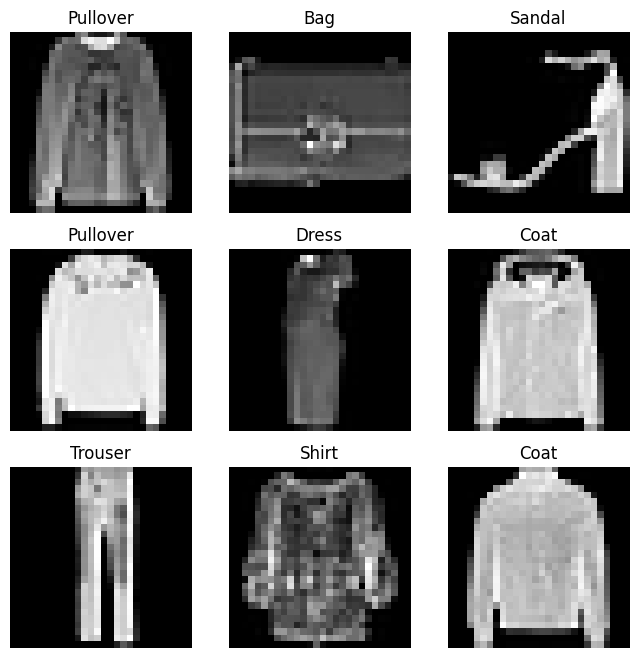

In [39]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8,8))
cols, rows = 3,3
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()


In [40]:
# A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. 

import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [ ]:
# DataLoader: pass samples in “minibatches”, reshuffle the data at every epoch to reduce model overfitting,
# and use Python’s multiprocessing to speed up data retrieval.

from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

torch.Size([64, 1, 28, 28]) torch.Size([64])


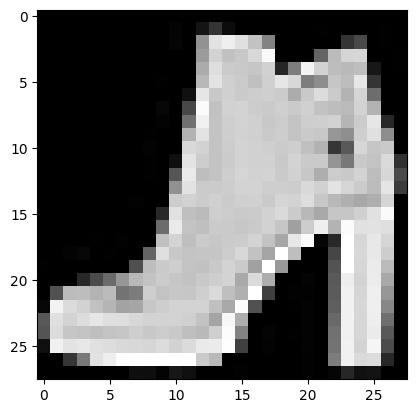

label: 9


In [ ]:
train_features, train_labels = next(iter(train_dataloader))
print(train_features.size(), train_labels.size())
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"label: {label}")

##### Transforms

In [51]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

##### Build the NN

In [60]:
# Every module in PyTorch subclasses the nn.Module.

import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")


Using cuda


In [61]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
X = torch.rand(1,28,28, device=device)
logits = model(X)
pred_prob = nn.Softmax(dim=1)(logits)
y_pred = pred_prob.argmax(dim=1)

tensor([5], device='cuda:0')

In [69]:
input_image = torch.rand(3,28,28)
flatten = nn.Flatten()
flat_image = flatten(input_image)
flat_image.shape, flat_image.size()

(torch.Size([3, 784]), torch.Size([3, 784]))

In [70]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


In [71]:
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[ 0.3769,  0.4053,  0.0242, -0.2446,  0.4975,  0.1889, -0.0395, -0.5682,
         -0.1053,  0.1884,  0.2980, -0.0774,  0.0494, -0.1302, -0.0660, -0.1018,
         -0.0182,  0.1908, -0.4182,  0.3781],
        [ 0.4174,  0.2574,  0.0468, -0.2243,  0.3007,  0.2450,  0.4794, -0.1902,
          0.0250,  0.1303,  0.1768, -0.1702,  0.1574, -0.3936, -0.3631,  0.4708,
         -0.0133,  0.4878, -0.3827,  0.5548],
        [ 0.3365,  0.3696,  0.2623, -0.1019,  0.9998,  0.1338,  0.3539, -0.3320,
          0.0237,  0.1544,  0.3552, -0.5109,  0.2161, -0.2654, -0.0304,  0.1093,
          0.0668, -0.0870, -0.1418,  0.2715]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.3769, 0.4053, 0.0242, 0.0000, 0.4975, 0.1889, 0.0000, 0.0000, 0.0000,
         0.1884, 0.2980, 0.0000, 0.0494, 0.0000, 0.0000, 0.0000, 0.0000, 0.1908,
         0.0000, 0.3781],
        [0.4174, 0.2574, 0.0468, 0.0000, 0.3007, 0.2450, 0.4794, 0.0000, 0.0250,
         0.1303, 0.1768, 0.0000, 0.1574, 0.0000, 0.00

In [74]:
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)
logits.shape

torch.Size([3, 10])

In [75]:
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)

In [77]:
# PyTorch stores nn.Linear(in_features, out_features) weights as a tensor of shape [out_features, in_features].

print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0313, -0.0227,  0.0357,  ...,  0.0065, -0.0003, -0.0093],
        [-0.0060,  0.0017,  0.0261,  ...,  0.0169,  0.0195,  0.0219]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([0.0294, 0.0040], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0019, -0.0180, -0.0087,  ...,  0.0023,  0.0207,  0.0435],
        [ 0.0395, -0.0054, -0.0363,  ...,  0.0116,  0.0408, -0.0110]],
       device='cuda:0', grad_fn=<Slic

##### AutoGrad

In [78]:
import torch

x = torch.ones(5)  # input tensor
y = torch.zeros(3)  # expected output
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w)+b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)

In [84]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x000001B103C31BD0>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x000001B103C322F0>


In [85]:
loss.backward()
print(w.grad)
print(b.grad)

tensor([[0.1264, 0.0623, 0.1004],
        [0.1264, 0.0623, 0.1004],
        [0.1264, 0.0623, 0.1004],
        [0.1264, 0.0623, 0.1004],
        [0.1264, 0.0623, 0.1004]])
tensor([0.1264, 0.0623, 0.1004])


In [86]:
# Disable gradient tracking 

z = torch.matmul(x, w)+b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w)+b
print(z.requires_grad)

True
False


In [87]:
z = torch.matmul(x, w)+b
z_det = z.detach()
print(z_det.requires_grad)

False


In [88]:
inp = torch.eye(4, 5, requires_grad=True)
out = (inp+1).pow(2).t()
out

tensor([[4., 1., 1., 1.],
        [1., 4., 1., 1.],
        [1., 1., 4., 1.],
        [1., 1., 1., 4.],
        [1., 1., 1., 1.]], grad_fn=<TBackward0>)

##### Optimizing model parameters

In [96]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NeuralNetwork()

In [97]:
learning_rate = 1e-3
batch_size = 64
epochs = 5

# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [98]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [99]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.293861  [   64/60000]
loss: 2.285830  [ 6464/60000]
loss: 2.264074  [12864/60000]
loss: 2.264752  [19264/60000]
loss: 2.256800  [25664/60000]
loss: 2.211200  [32064/60000]
loss: 2.232273  [38464/60000]
loss: 2.190563  [44864/60000]
loss: 2.182970  [51264/60000]
loss: 2.167316  [57664/60000]
Test Error: 
 Accuracy: 39.8%, Avg loss: 2.151584 

Epoch 2
-------------------------------
loss: 2.151479  [   64/60000]
loss: 2.144772  [ 6464/60000]
loss: 2.085161  [12864/60000]
loss: 2.108654  [19264/60000]
loss: 2.062852  [25664/60000]
loss: 1.986239  [32064/60000]
loss: 2.029927  [38464/60000]
loss: 1.942170  [44864/60000]
loss: 1.939511  [51264/60000]
loss: 1.880457  [57664/60000]
Test Error: 
 Accuracy: 54.9%, Avg loss: 1.872543 

Epoch 3
-------------------------------
loss: 1.894879  [   64/60000]
loss: 1.866798  [ 6464/60000]
loss: 1.747504  [12864/60000]
loss: 1.796634  [19264/60000]
loss: 1.680907  [25664/60000]
loss: 1.626734  [32064/600

##### Save and load models

In [101]:
import torch
import torchvision.models as models

torch.save(model.state_dict(), 'model_weights.pth')

model = NeuralNetwork() # we do not specify ``weights``, i.e. create untrained model
model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model.eval()

# Saving and Loading Models with Shapes
torch.save(model, 'model.pth')
model = torch.load('model.pth', weights_only=False)